# Import Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Load the Data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")

print("Path to dataset files:", path)

/opt/anaconda3/envs/stat230A/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/destinyogu/.cache/kagglehub/datasets/nadyinky/sephora-products-and-skincare-reviews/versions/2


In [9]:
path = "/Users/destinyogu/.cache/kagglehub/datasets/nadyinky/sephora-products-and-skincare-reviews/versions/2"
products_path = os.path.join(path, 'product_info.csv')
products_df = pd.read_csv(products_path)

In [10]:
pd.set_option("display.max_columns", None)

In [11]:
products_df.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [12]:
products = products_df.copy()

In [13]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   str    
 1   product_name        8494 non-null   str    
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   str    
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   str    
 8   variation_type      7050 non-null   str    
 9   variation_value     6896 non-null   str    
 10  variation_desc      1250 non-null   str    
 11  ingredients         7549 non-null   str    
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new              

In [14]:
products.describe()

,brand_id,loves_count,rating,reviews,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,child_count,child_max_price,child_min_price
count,8494.000000,8.494000e+03,8216.000000,8216.000000,8494.000000,451.000000,270.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,2754.000000,2754.000000
mean,5422.440546,2.917957e+04,4.194513,448.545521,51.655595,91.168537,20.207889,0.070285,0.071698,0.219096,0.073699,0.279374,1.631622,53.792023,39.665802
std,1709.595957,6.609212e+04,0.516694,1101.982529,53.669234,79.195631,24.327352,0.255642,0.258002,0.413658,0.261296,0.448718,5.379470,58.765894,38.685720
min,1063.000000,0.000000e+00,1.000000,1.000000,3.000000,0.000000,1.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000
25%,5333.000000,3.758000e+03,3.981725,26.000000,25.000000,45.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,19.000000
50%,6157.500000,9.880000e+03,4.289350,122.000000,35.000000,67.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,28.000000
75%,6328.000000,2.684125e+04,4.530525,418.000000,58.000000,108.500000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,59.000000,42.000000
max,8020.000000,1.401068e+06,5.000000,21281.000000,1900.000000,617.000000,320.000000,1.000000,1.000000,1.000000,1.000000,1.000000,105.000000,570.000000,400.000000


# Relevant Features

In [39]:
predictor = ['price_usd']
features = ['brand_name', 'size', 'ingredients', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive'
            , 'highlights', 'primary_category', 'secondary_category']

# Check for Duplicates

In [40]:
products.duplicated().sum()

np.int64(0)

No duplicates across all columns

In [41]:
products.duplicated(subset=['product_id']).sum()

np.int64(0)

No duplicates

# Check for Missing Values

In [42]:
products[predictor + features].isna().sum()

price_usd                0
brand_name               0
size                  1631
ingredients            945
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
dtype: int64

In [43]:
new_products = products[predictor + features].dropna()

In [44]:
new_products.shape

(5056, 12)

# Feature Engineering

In [45]:
new_products["primary_category"].value_counts()

primary_category
Skincare           1706
Makeup             1218
Hair                984
Fragrance           702
Bath & Body         246
Mini Size           188
Men                  11
Tools & Brushes       1
Name: count, dtype: int64

In [ ]:
new_products["primary_category"] = new_products["primary_category"].astype(str).str.strip()

dtype('float64')

In [46]:
if "brand_name" in new_products.columns:
       new_products["brand_name"] = new_products["brand_name"].astype(str).str.strip().str.title()

In [48]:
INGREDIENT_FLAGS = {
        "has_retinol":       r"retinol|retinoid|tretinoin|retinal\b",
        "has_niacinamide":   r"niacinamide|nicotinamide",
        "has_hyaluronic":    r"hyaluronic acid|sodium hyaluronate",
        "has_vitamin_c":     r"ascorbic acid|vitamin c|l-ascorbic|ascorbyl",
        "has_aha_bha":       r"glycolic acid|lactic acid|salicylic acid|mandelic acid|"
                              r"tartaric acid|malic acid|citric acid|aha|bha",
        "has_peptides":      r"peptide|palmitoyl|matrixyl|argireline|acetyl",
        "has_spf":           r"\bspf\b|sunscreen|zinc oxide|titanium dioxide|"
                              r"avobenzone|octinoxate",
        "has_fragrance":     r"\bfragrance\b|\bparfum\b|\bperfume\b",
        "has_alcohol":       r"alcohol denat|sd alcohol|denatured alcohol",
        "has_ceramides":     r"ceramide",
        "has_collagen":      r"collagen|hydrolyzed collagen",
        "has_bakuchiol":     r"bakuchiol",
        "has_vitamin_e":     r"tocopherol|vitamin e",
    }
 

ing = new_products["ingredients"].fillna("").astype(str).str.lower()
for flag, pattern in INGREDIENT_FLAGS.items():
    new_products[flag] = ing.str.contains(pattern, regex=True, na=False).astype(int)
    n = new_products[flag].sum()
    print(f"      {flag:<25}: {n:,} products ({n/len(new_products):.1%})")
 

      has_retinol              : 80 products (1.6%)
      has_niacinamide          : 394 products (7.8%)
      has_hyaluronic           : 1,195 products (23.6%)
      has_vitamin_c            : 643 products (12.7%)
      has_aha_bha              : 1,985 products (39.3%)
      has_peptides             : 717 products (14.2%)
      has_spf                  : 1,293 products (25.6%)
      has_fragrance            : 2,420 products (47.9%)
      has_alcohol              : 795 products (15.7%)
      has_ceramides            : 221 products (4.4%)
      has_collagen             : 99 products (2.0%)
      has_bakuchiol            : 56 products (1.1%)
      has_vitamin_e            : 1,865 products (36.9%)


In [49]:
def assign_brand_tier(df: pd.DataFrame) -> pd.DataFrame:
    """
    Assign a brand tier (Luxury / Mid-range / Accessible) based on
    median brand price. This is a data-driven segmentation:
      - Top tercile of median brand price   → Luxury
      - Middle tercile                       → Mid-range
      - Bottom tercile                       → Accessible
 
    This avoids hard-coding brand names (which change) and lets the
    data define the tiers. It also becomes a key categorical predictor
    that captures brand positioning independently of individual product price.
    """
    if "brand_name" not in df.columns:
        return df
 
    brand_median = df.groupby("brand_name")["price_usd"].median()
    terciles     = brand_median.quantile([1/3, 2/3])
 
    def tier(median_price):
        if median_price >= terciles[2/3]:
            return "Luxury"
        elif median_price >= terciles[1/3]:
            return "Mid-range"
        else:
            return "Accessible"
 
    df["brand_tier"] = df["brand_name"].map(brand_median).apply(tier)
    print(f"\n[Brand tiers]")
    print(df["brand_tier"].value_counts().to_string())
    return df

In [50]:
assign_brand_tier(new_products)


[Brand tiers]
brand_tier
Mid-range     1801
Accessible    1629
Luxury        1626


,price_usd,brand_name,size,ingredients,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,has_retinol,has_niacinamide,has_hyaluronic,has_vitamin_c,has_aha_bha,has_peptides,has_spf,has_fragrance,has_alcohol,has_ceramides,has_collagen,has_bakuchiol,has_vitamin_e,brand_tier
1,195.0,19-69,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury
2,195.0,19-69,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury
3,195.0,19-69,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury
4,195.0,19-69,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury
5,30.0,19-69,0.25 oz/ 7.5 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Warm &Spicy Scent', 'Unisex/ Genderless Scen...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8476,89.0,Yves Saint Laurent,2 oz/ 60 mL,"['Alcohol, Aqua / Water, Parfum / Fragrance, L...",0,0,0,0,0,"['Fresh Scent', 'Layerable Scent']",Fragrance,Men,0,0,0,0,0,0,0,1,0,0,0,0,0,Mid-range
8477,120.0,Yves Saint Laurent,3.4 oz / 100 mL,"['Alcohol, Parfum / Fragrance, Aqua / Water / ...",0,0,0,0,0,"['Layerable Scent', 'Woody & Earthy Scent']",Fragrance,Men,0,0,0,0,0,0,0,1,0,0,0,0,0,Mid-range
8486,99.0,Yves Saint Laurent,3.4 oz/ 100 mL,"['Alcohol, Parfum / Fragrance, Aqua / Water, L...",0,0,0,1,0,"['Fresh Scent', 'Layerable Scent']",Fragrance,Men,0,0,0,0,0,0,0,1,0,0,0,0,0,Mid-range
8490,106.0,Yves Saint Laurent,2 oz / 60 mL,"['Alcohol, Aqua / Water / Eau, Parfum / Fragra...",0,0,0,0,0,"['Layerable Scent', 'Woody & Earthy Scent']",Fragrance,Men,0,0,0,0,0,0,0,1,0,0,0,0,0,Mid-range


In [84]:
new_products['size'].value_counts()

size
1.7 oz/ 50 mL      361
1 oz/ 30 mL        306
0.5 oz/ 15 mL      129
3.4 oz/ 100 mL     120
1.7 oz / 50 mL     110
                  ... 
30 mL/ 1 oz          1
.3 oz / 9 mL         1
0.1 oz / 2.8 g       1
1.35 oz/40 mL        1
.11 oz / 3.2 mL      1
Name: count, Length: 1626, dtype: int64

In [85]:
test_products = new_products.copy()

In [88]:
import re

def parse_size(size_str):
    """
    Extract a standardized size in mL from the size string.
    Conversion: 1 fl oz = 29.5735 mL, 1 oz = 29.5735 mL
    Returns NaN if unparseable.
    """
    if pd.isna(size_str):
        return float("nan")

    s = str(size_str).lower().strip()

    # Try mL first (most common and no conversion needed)
    ml_match = re.search(r"([\d\.]+)\s*ml", s)
    if ml_match:
        return float(ml_match.group(1))

    # fl oz → mL
    floz_match = re.search(r"([\d\.]+)\s*fl\.?\s*oz", s)
    if floz_match:
        return round(float(floz_match.group(1)) * 29.5735, 2)

    # oz (non-fluid, e.g. creams/powders) → mL equivalent
    oz_match = re.search(r"([\d\.]+)\s*oz", s)
    if oz_match:
        return round(float(oz_match.group(1)) * 29.5735, 2)

    # g / gram (solid products)
    g_match = re.search(r"([\d\.]+)\s*g\b", s)
    if g_match:
        return float(g_match.group(1))

    return float("nan")


# Apply and log-transform
test_products["size_ml"]    = test_products["size"].apply(parse_size)
test_products["log_size"]   = np.log(test_products["size_ml"].where(test_products["size_ml"] > 0))

# Check how many parsed successfully
n_parsed = test_products["size_ml"].notna().sum()
n_total  = test_products["size"].notna().sum()
print(f"Parsed: {n_parsed:,} / {n_total:,} ({n_parsed/n_total:.1%})")

# Inspect failures — these are the unparseable strings
failures = test_products[test_products["size"].notna() & test_products["size_ml"].isna()]["size"].value_counts().head(20)
print(f"\nUnparseable size values:\n{failures.to_string()}")

Parsed: 4,916 / 5,056 (97.2%)

Unparseable size values:
size
1 Mask                                             9
60 Capsules                                        6
60 Pads                                            5
1 Month Supply / 120 Capsules                      5
5 Treatments                                       4
30 Capsules                                        4
10 Wipes                                           4
60 pads                                            4
1 / 30                                             2
30 Treatments + 5 Bonus                            2
1 Mask / 1 Mask                                    2
Tool w/ 2 Roller Heads / Tool w/ 2 Roller Heads    2
7 Individual Masks                                 2
60 Vegan Capsules                                  2
Standard                                           2
10 Masks                                           2
30 Day Supply                                      2
6 x Eye Masks                         

In [99]:
print(new_products['highlights'].value_counts()[:30])

highlights
['Layerable Scent', 'Floral Scent']                                                                                                45
['Vegan', 'Unisex/ Genderless Scent', 'Clean at Sephora', 'Cruelty-Free']                                                          42
['Floral Scent', 'Layerable Scent']                                                                                                36
['Vegan']                                                                                                                          32
['Vegan', 'Unisex/ Genderless Scent', 'Clean + Planet Positive', 'Without Phthalates', 'Hypoallergenic', 'Cruelty-Free']           19
['Unisex/ Genderless Scent', 'Layerable Scent', 'Without Parabens', 'Cruelty-Free']                                                16
['Vegan', 'Clean at Sephora']                                                                                                      16
['Floral Scent']                                   

In [102]:
HIGHLIGHT_FLAGS = {
    "clean_at_sephora":     "Clean at Sephora",
    "vegan":                "Vegan",
    "cruelty_free":         "Cruelty-Free",
    "fragrance_free":       "Fragrance Free",
    "hypoallergenic":       "Hypoallergenic",
    "sustainable":          "Sustainable Packaging",
}

for col_name, tag in HIGHLIGHT_FLAGS.items():
    test_products[f"hl_{col_name}"] = test_products["highlights"].apply(
        lambda tags: int(tag in tags)
    )
    n = test_products[f"hl_{col_name}"].sum()
    print(f"  hl_{col_name:<25}: {n:,} products ({n/len(test_products):.1%})")

  hl_clean_at_sephora         : 1,333 products (26.4%)
  hl_vegan                    : 2,117 products (41.9%)
  hl_cruelty_free             : 1,361 products (26.9%)
  hl_fragrance_free           : 441 products (8.7%)
  hl_hypoallergenic           : 103 products (2.0%)
  hl_sustainable              : 16 products (0.3%)


In [103]:
test_products.head()

,price_usd,brand_name,size,ingredients,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,has_retinol,has_niacinamide,has_hyaluronic,has_vitamin_c,has_aha_bha,has_peptides,has_spf,has_fragrance,has_alcohol,has_ceramides,has_collagen,has_bakuchiol,has_vitamin_e,brand_tier,log_price,size_ml,log_size,hl_clean_at_sephora,hl_vegan,hl_cruelty_free,hl_fragrance_free,hl_dermatologist_tested,hl_clinically_tested,hl_hypoallergenic,hl_sustainable,hl_sephora_collection,hl_carbonneutral
1,195.0,19-69,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury,5.273000,100.0,4.605170,0,0,0,0,0,0,0,0,0,0
2,195.0,19-69,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury,5.273000,100.0,4.605170,0,0,0,0,0,0,0,0,0,0
3,195.0,19-69,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury,5.273000,100.0,4.605170,0,0,0,0,0,0,0,0,0,0
4,195.0,19-69,3.4 oz/ 100 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury,5.273000,100.0,4.605170,0,0,0,0,0,0,0,0,0,0
5,30.0,19-69,0.25 oz/ 7.5 mL,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",0,0,1,0,0,"['Warm &Spicy Scent', 'Unisex/ Genderless Scen...",Fragrance,Women,0,0,0,0,0,0,0,1,1,0,0,0,0,Luxury,3.401197,7.5,2.014903,0,0,0,0,0,0,0,0,0,0


In [104]:
test_products[test_products['hl_clean_at_sephora'] == 1]

,price_usd,brand_name,size,ingredients,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,has_retinol,has_niacinamide,has_hyaluronic,has_vitamin_c,has_aha_bha,has_peptides,has_spf,has_fragrance,has_alcohol,has_ceramides,has_collagen,has_bakuchiol,has_vitamin_e,brand_tier,log_price,size_ml,log_size,hl_clean_at_sephora,hl_vegan,hl_cruelty_free,hl_fragrance_free,hl_dermatologist_tested,hl_clinically_tested,hl_hypoallergenic,hl_sustainable,hl_sephora_collection,hl_carbonneutral
14,38.0,54 Thrones,6 oz / 180 mL,"['Butyrospermum Parkii (Shea Nilotica) Butter,...",0,0,1,0,0,"['Clean at Sephora', 'Hydrating', 'Good for: D...",Bath & Body,Body Moisturizers,0,0,0,0,0,0,0,0,0,0,0,0,1,Accessible,3.637586,180.00,5.192957,1,0,0,0,0,0,0,0,0,0
17,12.0,54 Thrones,1 oz / 30 mL,"['Butyrospermum Parkii (Shea Nilotica) Butter,...",0,1,1,1,0,"['Clean at Sephora', 'Hydrating', 'Good for: D...",Bath & Body,Body Moisturizers,0,0,0,0,0,0,0,0,0,0,0,0,1,Accessible,2.484907,30.00,3.401197,1,0,0,0,0,0,0,0,0,0
46,39.0,Adwoa Beauty,16 oz/ 453 g,"['Water (Aqua), Butyrospermum Parkii (Shea But...",0,0,0,0,1,"['Vegan', 'Clean at Sephora', 'All Hair Types'...",Hair,Hair Styling & Treatments,0,0,0,0,0,0,0,1,0,0,0,0,0,Accessible,3.663562,473.18,6.159476,1,1,0,0,0,0,0,0,0,0
47,40.0,Adwoa Beauty,16 oz/ 453 mg,"['Water (Aqua), Behentrimonium Methosulfate, C...",0,0,0,0,1,"['Good for: Damage', 'Good for: Color Care', '...",Hair,Hair Styling & Treatments,0,0,0,0,0,0,0,1,0,0,0,0,1,Accessible,3.688879,473.18,6.159476,1,0,0,0,0,0,0,0,0,0
48,26.0,Adwoa Beauty,14 oz/ 414 mL,"['Water (Aqua), Behentrimonium Methosulfate, C...",0,0,0,0,1,"['Clean at Sephora', 'All Hair Types', 'Curl-E...",Hair,Hair Styling & Treatments,0,0,0,0,0,0,0,1,0,0,0,0,0,Accessible,3.258097,414.00,6.025866,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8384,47.0,Wishful,1.0 oz/ 30 mL,"['Water/Aqua/Eau, Glycerin, Methylpropanediol,...",0,0,0,0,1,"['Good for: Loss of firmness', 'Good for: Dryn...",Skincare,Treatments,0,1,1,0,0,1,0,1,0,0,0,0,1,Mid-range,3.850148,30.00,3.401197,1,0,1,0,0,0,0,0,0,0
8385,63.0,Wishful,1.04 oz/ 30 mL,"['Simmondsia Chinensis (Jojoba) Seed Oil, Capr...",0,0,0,0,1,"['Vegan', 'Good for: Dullness/Uneven Texture',...",Skincare,Moisturizers,0,0,0,0,0,0,0,0,0,0,0,0,0,Mid-range,4.143135,30.00,3.401197,1,1,1,0,0,0,0,0,0,0
8386,43.0,Wishful,1.94 oz/ 55 g,"['Water/Aqua/Eau, Butylene Glycol, Coco-Capryl...",0,0,0,0,1,"['Good for: Loss of firmness', 'Plumping', 'Co...",Skincare,Moisturizers,0,1,1,0,0,1,0,1,0,0,1,0,0,Mid-range,3.761200,57.37,4.049522,1,0,1,0,0,0,0,0,0,0
8387,39.0,Wishful,1.94 oz / 55 g,"['Glycerin, Water/Aqua/Eau, Triethylhexanoin, ...",0,0,0,0,1,"['Vegan', 'Vitamin C', 'Clean at Sephora', 'Fr...",Skincare,Masks,0,0,0,0,0,0,0,0,0,0,0,0,0,Mid-range,3.663562,57.37,4.049522,1,1,1,1,0,0,0,0,0,0


In [106]:
for col_name, tag in HIGHLIGHT_FLAGS.items():
    new_products[f"hl_{col_name}"] = new_products["highlights"].apply(
        lambda tags: int(tag in tags)
    )

# EDA

Text(0.5, 0, 'Price (USD)')

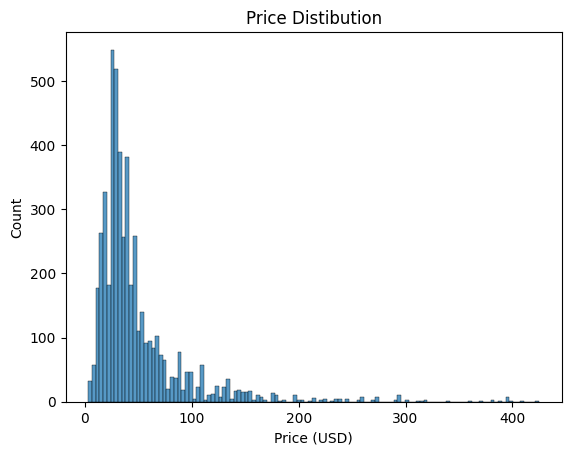

In [53]:
# Outcome Distribution
sns.histplot(new_products["price_usd"])
plt.title("Price Distibution")
plt.xlabel("Price (USD)")

Right skewed distribution --> log transformation to make more normal

Text(0.5, 0, 'log(Price (USD))')

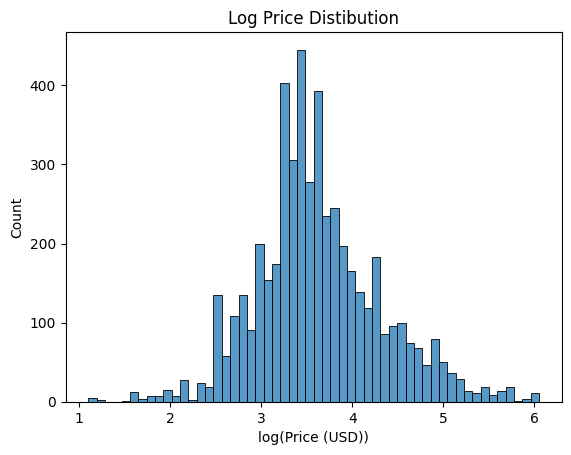

In [55]:
sns.histplot(np.log(new_products["price_usd"]))
plt.title("Log Price Distibution")
plt.xlabel("log(Price (USD))")

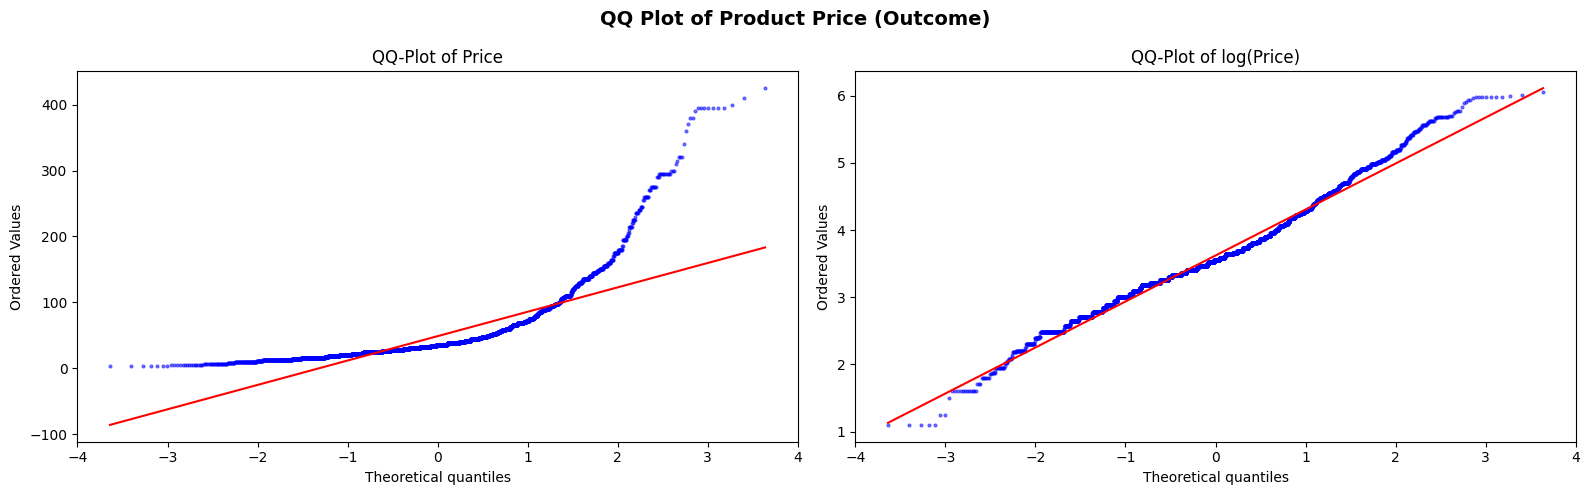

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("QQ Plot of Product Price (Outcome)", fontsize=14, fontweight="bold")
stats.probplot(new_products["price_usd"].dropna(), dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot of Price")
axes[0].get_lines()[0].set(color='blue', markersize=2, alpha=0.5)
axes[0].get_lines()[1].set(color='red')

stats.probplot(np.log(new_products["price_usd"]).dropna(), dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot of log(Price)")
axes[1].get_lines()[0].set(color='blue', markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color='red')

plt.tight_layout()

In [67]:
new_products['log_price'] = np.log(new_products['price_usd'])

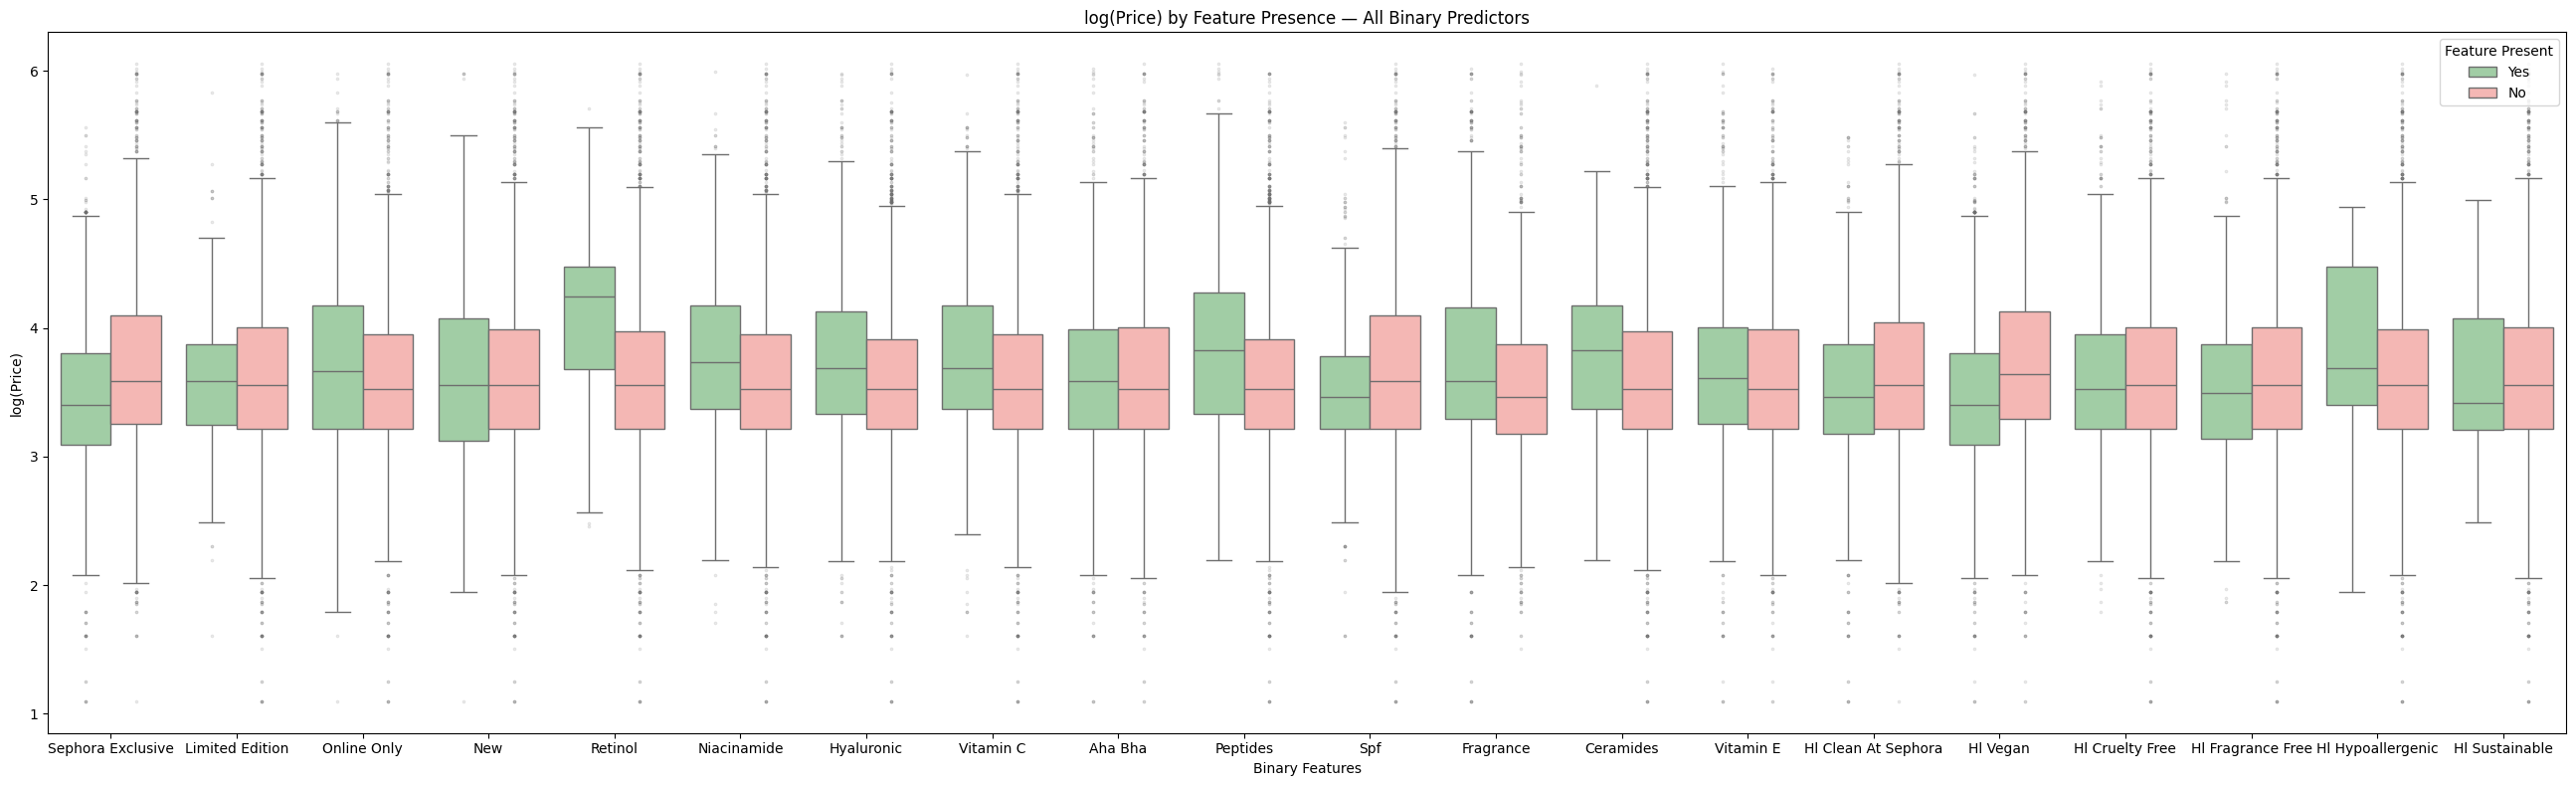

In [112]:
# Price by binary features
bin_cols = [
    "sephora_exclusive", "limited_edition", "online_only", "new",
    "has_retinol", "has_niacinamide", "has_hyaluronic", "has_vitamin_c",
    "has_aha_bha", "has_peptides", "has_spf", "has_fragrance",
    "has_ceramides", "has_vitamin_e", "hl_clean_at_sephora", "hl_vegan",
    "hl_cruelty_free", "hl_fragrance_free", "hl_hypoallergenic", "hl_sustainable"
]

# Melt to long format: one row per product × feature combination
long_df = pd.melt(
    new_products[bin_cols + ['log_price']],
    id_vars="log_price",
    var_name="feature",
    value_name="present"
)
long_df["present"] = long_df["present"].map({1: "Yes", 0: "No"})
long_df["feature"] = long_df["feature"].str.replace("has_", "").str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(26, 8))
sns.boxplot(
    data=long_df, x="feature", y="log_price", hue="present",
    hue_order=["Yes", "No"],
    palette= ['#9ad49f', '#ffada9'],
    flierprops={"marker": ".", "alpha": 0.2, "markersize": 3},
    ax=ax
)
ax.set(title="log(Price) by Feature Presence — All Binary Predictors",
       xlabel="Binary Features", ylabel="log(Price)")

ax.legend(title="Feature Present", loc="upper right")
plt.tight_layout()

/var/folders/z0/pslqf_691f94wn6r6l2rvjgm0000gn/T/ipykernel_84332/2471975604.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z0/pslqf_691f94wn6r6l2rvjgm0000gn/T/ipykernel_84332/2471975604.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z0/pslqf_691f94wn6r6l2rvjgm0000gn/T/ipykernel_84332/2471975604.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


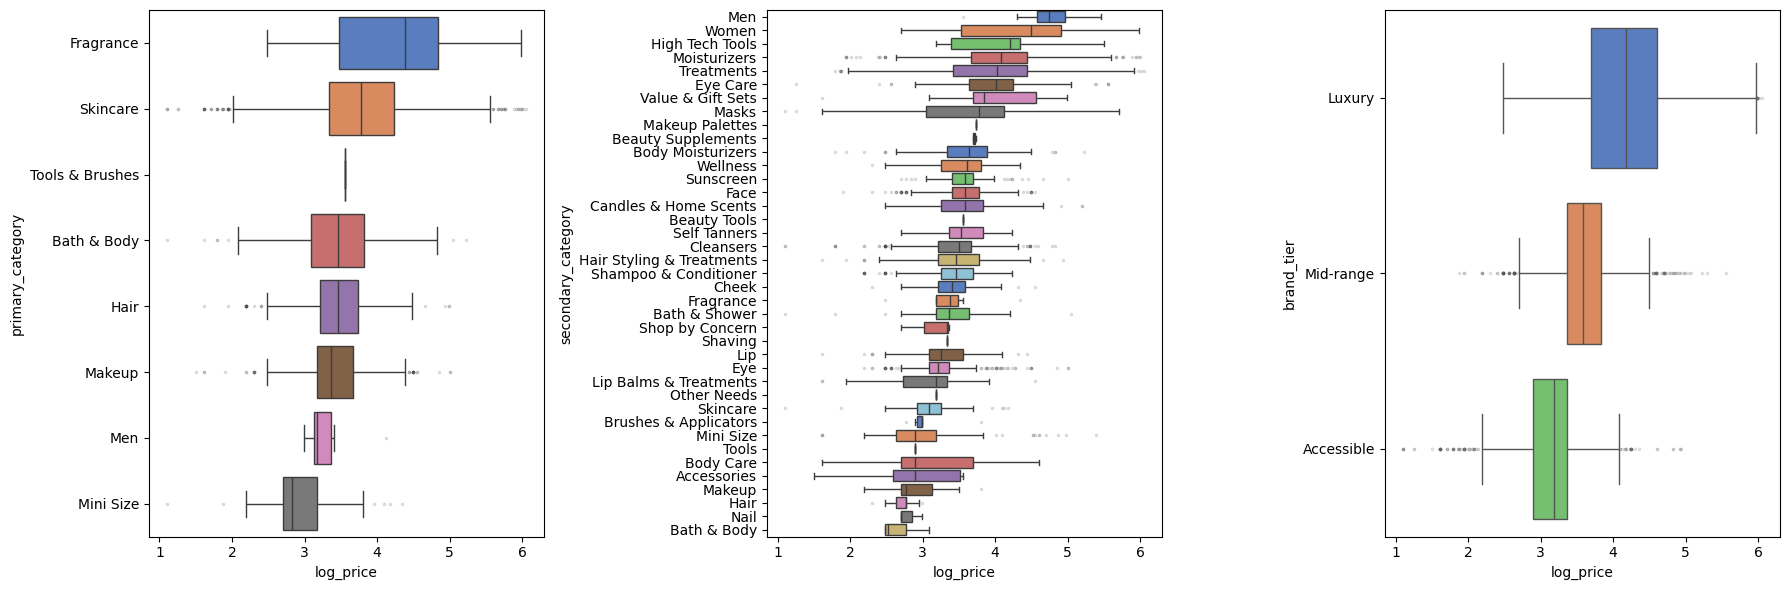

In [83]:
# Price by categorical features
cat_cols = ["primary_category", "secondary_category", "brand_tier"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, cat_cols):
    order = (new_products.groupby(col)["log_price"]
               .median()
               .sort_values(ascending=False)
               .index)

    sns.boxplot(
        data=new_products, x="log_price", y=col,
        order=order, palette="muted", ax=ax,
        flierprops={"marker": ".", "alpha": 0.2, "markersize": 3},
        orient = 'h'
    )

plt.tight_layout()
plt.show()

In [ ]:
# # Price by continuous features
# continuous_cols = ["log_price", "log_loves", "log_reviews", "rating"]

# # Color by brand tier if available
# hue_col = "brand_tier" if "brand_tier" in df.columns else None
# hue_order = ["Luxury", "Mid-range", "Accessible"]

# sample = new_products[continuous_cols + ([hue_col] if hue_col else [])].dropna()
# sample = sample.sample(min(2000, len(sample)), random_state=42)  # subsample for speed

# g = sns.pairplot(
#     sample,
#     vars=continuous_cols,
#     hue=hue_col,
#     hue_order=hue_order if hue_col else None,
#     palette=["#2E4057", "#048A81", "#E07A5F"],
#     diag_kind="kde",          # density on diagonal instead of histogram
#     plot_kws={"alpha": 0.3, "s": 15},
#     diag_kws={"linewidth": 1.5}
# )
# g.figure.suptitle("Pair Plot — Continuous Predictors colored by Brand Tier",
#                    y=1.02, fontsize=13, fontweight="bold")
# plt.show()

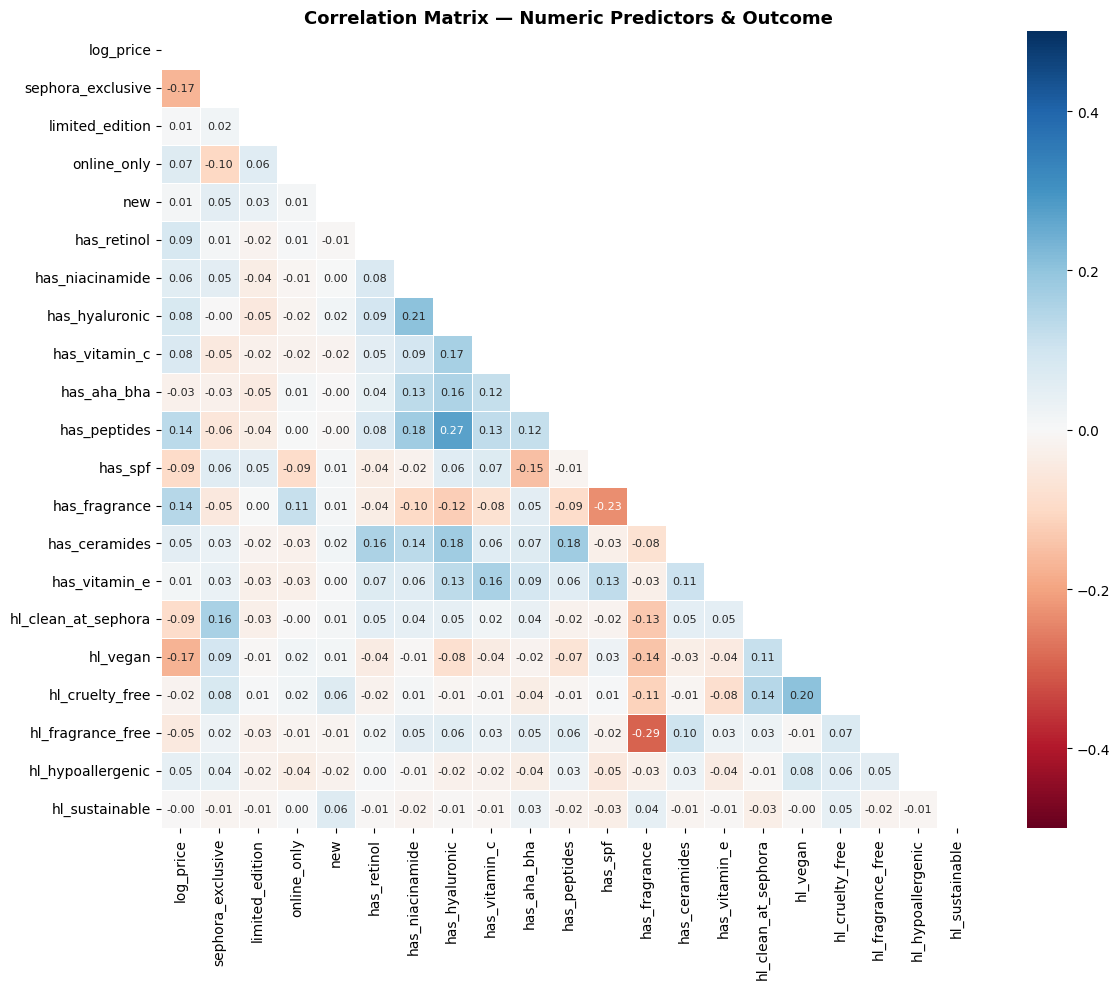

In [113]:
# Correlation Heatmap
numeric_cols = (
    ["log_price"]
    + bin_cols
)
numeric_cols = [c for c in numeric_cols if c in new_products.columns]
corr = new_products[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu",
    center=0, vmin=-0.5, vmax=0.5, ax=ax,
    linewidths=0.5, annot_kws={"size": 8}
)
ax.set_title("Correlation Matrix — Numeric Predictors & Outcome", fontsize=13, fontweight="bold")
plt.tight_layout()

# Print high correlations (|r| > 0.3) — potential multicollinearity
high_corr = (corr.abs()
                .where(mask == False)
                .stack()
                .reset_index()
                .rename(columns={0: "r", "level_0": "var1", "level_1": "var2"}))
high_corr = high_corr[
    (high_corr["var1"] != high_corr["var2"]) &
    (high_corr["r"] > 0.30)
].sort_values("r", ascending=False)
if len(high_corr) > 0:
    print(f"\n      High correlations (|r| > 0.30) — watch for VIF issues:")
    print(high_corr.to_string(index=False))